# Standard Gaussian Naive Bayes - Kidney Stone Risk Prediction Dataset

In [1]:
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score
from sklearn.naive_bayes import GaussianNB
import pickle, json, os
import warnings; warnings.filterwarnings("ignore")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


In [2]:
with open("../data/processed_data.pkl","rb") as f: data = pickle.load(f)
X_train=data["X_train"]; X_test=data["X_test"]
y_train=data["y_train"]; y_test=data["y_test"]
feature_names=data["feature_names"]
print(f"Training: {X_train.shape} | Test: {X_test.shape}")


Training: (3200, 23) | Test: (800, 23)


In [3]:
N_RUNS=30; detail_accs=[]; detail_f1s=[]; detail_precs=[]; detail_recs=[]
extra = ExtraMetrics()
for run in range(N_RUNS):
    m=GaussianNB()
    _t0 = time.perf_counter()
    m.fit(X_train,y_train)
    train_time = time.perf_counter() - _t0
    yp=m.predict(X_test)
    # Score the non-private fit on the training partition too, so the
    # generalisation gap can be read next to the held-out metrics.
    y_train_pred = m.predict(X_train)
    detail_accs.append(accuracy_score(y_test,yp)); detail_f1s.append(f1_score(y_test,yp,zero_division=0))
    extra.add(y_test, yp, model=m, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
    detail_precs.append(precision_score(y_test,yp,zero_division=0)); detail_recs.append(recall_score(y_test,yp,zero_division=0))
    if run==0: print(f"  Run 1/{N_RUNS} | Acc: {detail_accs[-1]:.4f} | F1: {detail_f1s[-1]:.4f}")
print(f"  ... (all {N_RUNS} runs identical - GNB is deterministic)")


  Run 1/30 | Acc: 0.8900 | F1: 0.8388
  ... (all 30 runs identical - GNB is deterministic)


In [4]:
accuracy=float(np.mean(detail_accs)); f1=float(np.mean(detail_f1s))
precision=float(np.mean(detail_precs)); recall=float(np.mean(detail_recs))
print("="*60)
print("STANDARD GAUSSIAN NAIVE BAYES - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}"); print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}"); print(f"Recall:    {recall:.4f}")
print("="*60)


STANDARD GAUSSIAN NAIVE BAYES - PERFORMANCE METRICS
Accuracy:  0.8900
F1-Score:  0.8388
Precision: 0.9828
Recall:    0.7316


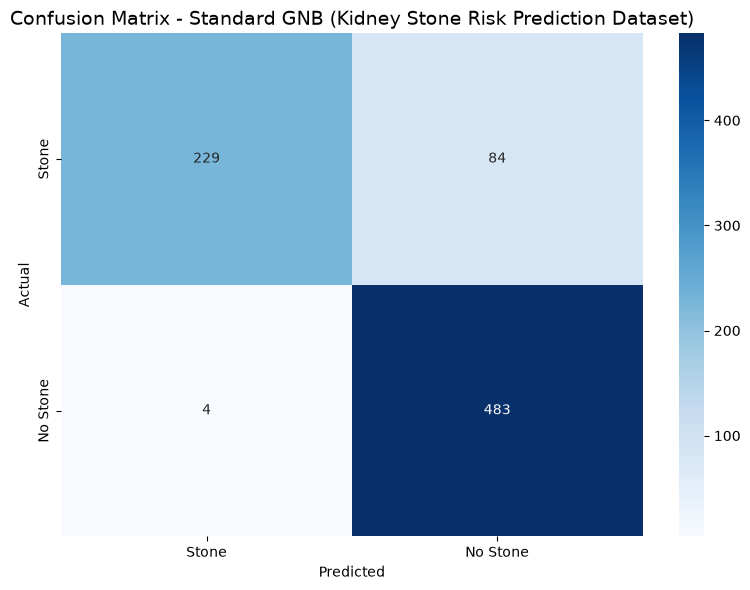

In [5]:
gnb_model=GaussianNB()
_t0 = time.perf_counter()
gnb_model.fit(X_train,y_train)
train_time = time.perf_counter() - _t0
y_pred=gnb_model.predict(X_test)
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = gnb_model.predict(X_train)
cm=confusion_matrix(y_test,y_pred)
TN,FP,FN,TP=cm[0,0],cm[0,1],cm[1,0],cm[1,1]
custom_cm=np.array([[TP,FN],[FP,TN]])
plt.figure(figsize=(8,6))
sns.heatmap(custom_cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Stone","No Stone"],yticklabels=["Stone","No Stone"])
plt.title("Confusion Matrix - Standard GNB (Kidney Stone Risk Prediction Dataset)",fontsize=14)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()


In [6]:
print("Classification Report:")
print(classification_report(y_pred,y_test,target_names=["No Stone","Stone"]))


Classification Report:
              precision    recall  f1-score   support

    No Stone       0.99      0.85      0.92       567
       Stone       0.73      0.98      0.84       233

    accuracy                           0.89       800
   macro avg       0.86      0.92      0.88       800
weighted avg       0.92      0.89      0.89       800



In [7]:
os.makedirs("output",exist_ok=True)
pd.DataFrame({**{_k: [_v] for _k, _v in extra.means().items()}, "model":["Standard_GNB"],"accuracy":[accuracy],"f1_score":[f1],"precision":[precision],"recall":[recall]}).to_csv("output/baseline_results.csv",index=False)
with open("output/std_gnb_report.json","w") as f: json.dump({"model_type":"Standard Gaussian Naive Bayes","dataset":"Kidney Stone Risk Prediction Dataset","metrics":{**extra.means(), "accuracy":float(accuracy),"f1_score":float(f1),"precision":float(precision),"recall":float(recall)}},f,indent=4)
print("Baseline saved to output/")

# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model
export_model(gnb_model, 'output/model/std_gnb_model.pkl')


print("Added metrics:")
print(extra.describe())

Baseline saved to output/


Model successfully exported to output/model/std_gnb_model.pkl
Added metrics:
  Train Acc:      0.8997 ± 0.0000
  Balanced Acc:   0.8617 ± 0.0000
  AUROC:          0.9393 ± 0.0000
  Train Time (s): 0.0003 ± 0.0001
